
Mssing Rate  : 0.05
Missing MSE  : 0.009971278
Missing PSNR : 20.012491 dB
Full PSNR    : 33.023853 dB
Full SSIM    : 0.9058332669607401
Missing SSIM : 0.8658875


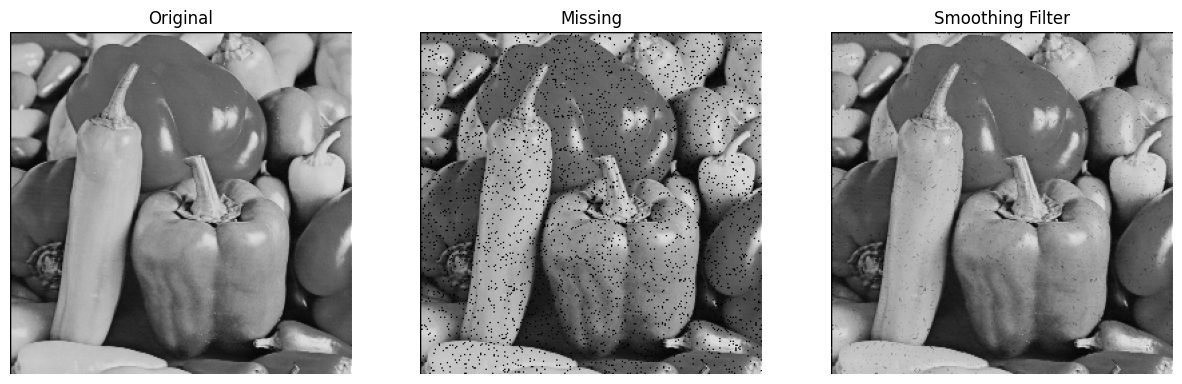

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from scipy.ndimage import uniform_filter
from skimage.metrics import structural_similarity as ssim

# ============================================
# 画像読み込み
# ============================================

img = Image.open("Images/Peppers.png").convert("L")

img = img.resize((256,256))

img_array = np.array(img).astype(np.float32)

# 0～1正規化
img_array = img_array / 255.0

# ============================================
# 欠損作成
# ============================================

height, width = img_array.shape

mask = np.ones(
    img_array.shape,
    dtype=bool
)

np.random.seed(42)

# 欠損率10%
mr=0.05 #"mr"：missing rate 欠損率
num_missing = int(
    height * width * mr
)

indices = np.random.choice(
    height * width,
    num_missing,
    replace=False
)

missing_points = [
    (idx // width, idx % width)
    for idx in indices
]

for i, j in missing_points:

    mask[i, j] = False

# 欠損画像
img_missing = img_array.copy()

img_missing[~mask] = np.nan

# ============================================
# 平滑化フィルタ補間
# ============================================

# NaNを0に置換
smooth_input = np.nan_to_num(
    img_missing,
    nan=0
)

# 3×3平均化フィルタ
smooth_filtered = uniform_filter(
    smooth_input,
    size=3
)

# 補間結果
final_img = img_missing.copy()

# 欠損部分のみ補間値を採用
final_img[~mask] = smooth_filtered[~mask]

# ============================================
# Missing MSE
# ============================================

missing_mse = np.mean(

    (
        img_array[~mask]
        -
        final_img[~mask]

    ) ** 2
)

# ============================================
# Missing PSNR
# ============================================

if missing_mse == 0:

    missing_psnr = float("inf")

else:

    missing_psnr = 10 * np.log10(
        1.0 / missing_mse
    )

# ============================================
# Full PSNR
# ============================================

full_mse = np.mean(

    (
        img_array
        -
        final_img

    ) ** 2
)

if full_mse == 0:

    full_psnr = float("inf")

else:

    full_psnr = 10 * np.log10(
        1.0 / full_mse
    )

# ============================================
# SSIM
# ============================================

full_ssim, ssim_map = ssim(
    img_array,
    final_img,
    data_range=1.0,
    full=True
)

missing_ssim = np.mean(
    ssim_map[~mask]
)

# ============================================
# 結果表示
# ============================================

print("\n==============================")
print("Mssing Rate  :", mr )
print("Missing MSE  :", missing_mse)
print("Missing PSNR :", missing_psnr, "dB")
print("Full PSNR    :", full_psnr, "dB")
print("Full SSIM    :", full_ssim)
print("Missing SSIM :", missing_ssim)
print("==============================")

# ============================================
# 可視化
# ============================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

# 元画像
ax[0].imshow(
    img_array,
    cmap='gray'
)

ax[0].set_title(
    "Original"
)

# 欠損画像
ax[1].imshow(
    np.nan_to_num(
        img_missing,
        nan=0
    ),
    cmap='gray'
)

ax[1].set_title(
    "Missing"
)

# 補間結果
ax[2].imshow(
    final_img,
    cmap='gray'
)

ax[2].set_title(
    "Smoothing Filter"
)

for i in range(3):

    ax[i].axis("off")

plt.show()